In [2]:
!pip install pandas_ta_classic


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time
import pandas_ta_classic as ta
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier

In [15]:
TICKER = "ECH"
START = "2009-12-12"
END = "2020-01-01" # paper: pre-pandemic window, 01/01/2009-01/01/2020
N_FOLDS = 10
RANDOM_STATE = 0
csv_filename = "ECH-adj-data.csv"

In [14]:
raw = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
time.sleep(2)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]
raw = raw.rename(columns=str.title) # Open, High, Low, Close, Adj Close, Volume


1 Failed download:
['ECH']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [74]:
df = pd.read_csv(
    csv_filename,
    header=[0, 1],      # Read the two header rows
    index_col=0,
    parse_dates=True
)

# Flatten the MultiIndex columns
df.columns = df.columns.get_level_values(0).str.lower()

# Make sure numeric columns are numeric
numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(df.head())
print(df.dtypes)

Price           close       high        low       open  volume
Date                                                          
2009-12-14  35.917553  36.069020  35.496079  35.627787  212300
2009-12-15  35.792431  35.943901  35.726576  35.726576  122100
2009-12-16  35.831932  36.220479  35.759491  36.220479  201500
2009-12-17  35.700222  35.772663  35.298504  35.324846   72300
2009-12-18  35.818764  35.897790  35.232651  35.897790  104900
Price
close     float64
high      float64
low       float64
open      float64
volume      int64
dtype: object


In [75]:
df.shape

(2529, 5)

In [76]:
df.ta.strategy(ta.AllStrategy)

In [77]:
df.head(10)

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,35.917553,36.069020,35.496079,35.627787,212300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,35.850051,NaN,NaN,NaN,NaN
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN
2009-12-21,35.957050,35.976809,35.568503,35.693630,54700,35.766518,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.763921,35.864853,NaN,NaN,NaN,NaN
2009-12-22,35.590317,35.907497,35.583707,35.907497,234300,35.741092,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.397188,35.667960,NaN,NaN,NaN,NaN
2009-12-23,35.729084,35.808378,35.425120,35.808378,37700,35.684471,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.701152,35.672917,NaN,NaN,NaN,NaN
2009-12-24,35.788551,35.993398,35.788551,35.993398,105000,35.737745,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.760619,35.839763,NaN,NaN,NaN,NaN


In [78]:
df.shape

(2529, 412)

In [79]:
delta_open = df["open"].diff()
df["y"] = (delta_open > 0).astype(int) # 1 if Open increased, 0 otherwise
df = df.iloc[1:] # first row has no lagged Open; order decreases by one

In [80]:
df.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,y
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN,1
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN,1
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN,0
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN,1
2009-12-21,35.957050,35.976809,35.568503,35.693630,54700,35.766518,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.763921,35.864853,NaN,NaN,NaN,NaN,0


In [81]:
df.isna().sum()

Price
close         0
high          0
low           0
open          0
volume        0
             ..
WILLR_14     12
WMA_10        8
ZL_EMA_10    12
ZS_30        28
y             0
Length: 413, dtype: int64

In [82]:
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0])

Price
ABER_ZG_5_15        3
ABER_SG_5_15       13
ABER_XG_5_15       13
ABER_ATR_5_15      13
ACCBL_20           18
                   ..
VWMACDs_12_26_9    32
WILLR_14           12
WMA_10              8
ZL_EMA_10          12
ZS_30              28
Length: 228, dtype: int64


In [83]:
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

Price
ASIN               2528
ACOS               2528
PSARs_0.02_0.2     1345
SUPERTs_7_3.0      1337
QQEs_14_5_4.236    1316
                   ... 
ABER_ZG_5_15          3
STOCHFk_5_3           3
OBVe_4                2
RAINBOW_3             2
RAINBOW_2             1
Length: 228, dtype: int64


In [84]:
print(df.shape)
print(df.isna().sum().max())
print(df.columns[df.isna().all()])
print(len(df.columns[df.isna().all()]))

(2528, 413)
2528
Index(['ACOS', 'ASIN'], dtype='object', name='Price')
2


In [85]:
df = df.dropna(axis=1, how='all')

In [86]:
print(df.isna().sum().sort_values(ascending=False).head(10))

Price
PSARs_0.02_0.2     1345
SUPERTs_7_3.0      1337
QQEs_14_5_4.236    1316
QQEl_14_5_4.236    1281
SUPERTl_7_3.0      1196
PSARl_0.02_0.2     1183
HILOl_13_21        1074
HILOs_13_21        1054
VFI_130             260
TRIXs_30_9           95
dtype: int64


In [87]:
print((df.isna().sum(axis=1) == 0).sum())

print(df.isna().sum().sort_values(ascending=False).head(20))

print(df.shape)

0
Price
PSARs_0.02_0.2       1345
SUPERTs_7_3.0        1337
QQEs_14_5_4.236      1316
QQEl_14_5_4.236      1281
SUPERTl_7_3.0        1196
PSARl_0.02_0.2       1183
HILOl_13_21          1074
HILOs_13_21          1054
VFI_130               260
TRIXs_30_9             95
TRIX_30_9              87
ISB_26                 76
QQEb_s_14_5_4.236      69
QQEb_l_14_5_4.236      69
QQE_14_5_4.236         69
KVOs_34_55_13          65
TRIXs_18_9             59
TRIXh_18_9             59
KVO_34_55_13           53
T3_10_0.7              53
dtype: int64
(2528, 411)


In [88]:
df = df.dropna(axis=1, how='all')

In [89]:
df

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,y
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN,1
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN,1
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN,0
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN,1
2009-12-21,35.957050,35.976809,35.568503,35.693630,54700,35.766518,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.763921,35.864853,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,26.039921,26.210978,25.907737,26.086571,134300,26.130113,26.684685,25.575542,0.554571,24.128291,...,0.999199,0.711398,0.287801,-15.655932,26.049639,-33.626162,26.134064,26.140258,0.920012,0
2019-12-26,26.102119,26.156547,25.946610,26.039918,295400,26.111451,26.643047,25.579855,0.531596,24.289879,...,1.065922,0.674276,0.391647,-15.500423,26.076849,-36.687273,26.130945,26.131910,0.916694,0
2019-12-27,26.016590,26.164325,25.767777,26.071018,209700,26.086570,26.609163,25.563978,0.522593,24.465041,...,1.096452,0.590350,0.506102,-15.648158,25.991321,-44.919163,26.105457,26.060049,0.778482,1


In [90]:
threshold = int(len(df) * 0.70)  # Keep columns with at least 70% non-NaN values
df = df.dropna(axis=1, thresh=threshold)
df

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,y
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN,1
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN,1
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN,0
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN,1
2009-12-21,35.957050,35.976809,35.568503,35.693630,54700,35.766518,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.763921,35.864853,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,26.039921,26.210978,25.907737,26.086571,134300,26.130113,26.684685,25.575542,0.554571,24.128291,...,0.999199,0.711398,0.287801,-15.655932,26.049639,-33.626162,26.134064,26.140258,0.920012,0
2019-12-26,26.102119,26.156547,25.946610,26.039918,295400,26.111451,26.643047,25.579855,0.531596,24.289879,...,1.065922,0.674276,0.391647,-15.500423,26.076849,-36.687273,26.130945,26.131910,0.916694,0
2019-12-27,26.016590,26.164325,25.767777,26.071018,209700,26.086570,26.609163,25.563978,0.522593,24.465041,...,1.096452,0.590350,0.506102,-15.648158,25.991321,-44.919163,26.105457,26.060049,0.778482,1


In [91]:
df = df.dropna()

print(df.shape)

(2242, 403)


In [92]:
df.shape

(2242, 403)

In [93]:
df.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,y
Date,,,,,,,,,,,,,,,,,,,,,
2010-12-28,51.256416,51.982935,51.169764,51.749650,570300,52.174462,52.869998,51.478926,0.695536,50.805990,...,0.337603,-0.244588,0.582192,20.732866,51.416383,-96.398767,52.349782,51.669756,-0.787179,0
2010-12-29,51.898556,52.045257,51.591819,51.591819,138700,51.909184,52.610940,51.207427,0.701757,50.873826,...,0.330604,-0.254841,0.585446,21.375006,51.858547,-69.711810,52.221854,51.614816,-0.042280,0
2010-12-30,52.778770,52.778770,52.058604,52.058604,202700,51.941242,52.654896,51.227588,0.713654,50.882883,...,0.366199,-0.204628,0.570826,22.255220,52.598729,-33.130579,52.264347,51.925088,1.010378,1
2010-12-31,53.078838,53.118851,52.692082,52.898799,102400,52.095980,52.790508,51.401452,0.694528,50.935707,...,0.315284,-0.226876,0.542160,22.641977,52.992152,-20.659925,52.363410,52.405614,1.390252,1
2011-01-03,53.525608,53.525608,52.872128,53.212207,237000,52.424934,53.116725,51.733142,0.691792,51.019258,...,0.322373,-0.158531,0.480904,23.295457,53.362238,-2.092425,52.543653,53.021830,1.868274,1


In [94]:
row_nan_counts = df.isna().sum(axis=1)

print(row_nan_counts.describe())

count    2242.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64


In [95]:
print(df.isna().sum().sort_values(ascending=False).head(10))

Price
y                0
close            0
high             0
low              0
open             0
volume           0
ABER_ZG_5_15     0
ABER_SG_5_15     0
ABER_XG_5_15     0
ABER_ATR_5_15    0
dtype: int64


In [96]:
print(df.isna().sum().max())

0


In [97]:
non_feature_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "y"]

In [98]:
df = df.dropna()
df

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,y
Date,,,,,,,,,,,,,,,,,,,,,
2010-12-28,51.256416,51.982935,51.169764,51.749650,570300,52.174462,52.869998,51.478926,0.695536,50.805990,...,0.337603,-0.244588,0.582192,20.732866,51.416383,-96.398767,52.349782,51.669756,-0.787179,0
2010-12-29,51.898556,52.045257,51.591819,51.591819,138700,51.909184,52.610940,51.207427,0.701757,50.873826,...,0.330604,-0.254841,0.585446,21.375006,51.858547,-69.711810,52.221854,51.614816,-0.042280,0
2010-12-30,52.778770,52.778770,52.058604,52.058604,202700,51.941242,52.654896,51.227588,0.713654,50.882883,...,0.366199,-0.204628,0.570826,22.255220,52.598729,-33.130579,52.264347,51.925088,1.010378,1
2010-12-31,53.078838,53.118851,52.692082,52.898799,102400,52.095980,52.790508,51.401452,0.694528,50.935707,...,0.315284,-0.226876,0.542160,22.641977,52.992152,-20.659925,52.363410,52.405614,1.390252,1
2011-01-03,53.525608,53.525608,52.872128,53.212207,237000,52.424934,53.116725,51.733142,0.691792,51.019258,...,0.322373,-0.158531,0.480904,23.295457,53.362238,-2.092425,52.543653,53.021830,1.868274,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-15,25.812452,26.169342,25.098671,25.370219,1816600,24.366789,25.257199,23.476379,0.890410,25.032656,...,-0.972498,-0.030607,-0.941890,-15.080540,25.723229,-46.315804,24.935886,24.175809,-0.943786,1
2019-11-18,25.812452,26.021932,25.533147,25.936588,936300,24.457305,25.320940,23.593670,0.863635,24.970903,...,-0.871940,0.091471,-0.963411,-15.080540,25.794996,-38.342019,25.013188,24.780899,-0.883784,1
2019-11-19,25.455564,25.509874,25.098672,25.509874,603300,24.756782,25.610427,23.903137,0.853645,24.816774,...,-0.840739,0.126062,-0.966800,-15.437427,25.379919,-45.149867,25.049301,25.195566,-0.994106,0


In [99]:
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_raw = df[feature_cols].astype(float)
y = df["y"].to_numpy()

In [100]:
X_raw = df[feature_cols].astype(float)
X_norm = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())

In [101]:
X_norm.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-12-28,0.929551,0.951881,0.946771,0.954476,0.278669,0.991187,0.988130,0.991711,0.276951,0.992853,...,1.000000,0.542369,0.338808,0.587802,0.937305,0.939411,0.036012,0.993757,0.957412,0.418595
2010-12-29,0.949487,0.953825,0.959967,0.949564,0.057415,0.982626,0.979878,0.982858,0.281661,0.995127,...,0.998901,0.541312,0.335943,0.588330,0.953016,0.953179,0.302882,0.989637,0.955681,0.530591
2010-12-30,0.976814,0.976705,0.974563,0.964093,0.090224,0.983661,0.981278,0.983515,0.290671,0.995430,...,0.999074,0.546686,0.349975,0.585959,0.974550,0.976226,0.668694,0.991005,0.965454,0.688858
2010-12-31,0.986130,0.987312,0.994370,0.990245,0.038807,0.988654,0.985598,0.989184,0.276187,0.997200,...,0.998927,0.538999,0.343758,0.581309,0.984012,0.988476,0.793401,0.994196,0.980590,0.745972
2011-01-03,1.000000,1.000000,1.000000,1.000000,0.107807,0.999269,0.995990,1.000000,0.274115,1.000000,...,0.997967,0.540069,0.362857,0.571373,1.000000,1.000000,0.979076,1.000000,1.000000,0.817842


In [102]:
X_norm.shape

(2242, 402)

In [103]:
np.isinf(X_norm).sum().sum()

np.int64(0)

In [104]:
print("Infinite values:", np.isinf(X_norm).sum().sum())
print("NaN values:", X_norm.isna().sum().sum())
print("Shape:", X_norm.shape)

Infinite values: 0
NaN values: 38114
Shape: (2242, 402)


In [105]:
nan_counts = X_norm.isna().sum().sort_values(ascending=False)
print(nan_counts.head(30))

Price
CDL_3STARSINSOUTH       2242
CDL_BREAKAWAY           2242
CDL_CONCEALBABYSWALL    2242
VFI_130                 2242
CDL_COUNTERATTACK       2242
DIV                     2242
SQZPRO_NO               2242
close_XA_close          2242
close_X_close           2242
TANH                    2242
SQZ_NO                  2242
CDL_IDENTICAL3CROWS     2242
CDL_KICKING             2242
CDL_KICKINGBYLENGTH     2242
CDL_MATHOLD             2242
SUB                     2242
CDL_RISEFALL3METHODS    2242
RAINBOW_10                 0
PPOs_12_26_9               0
PPOh_12_26_9               0
PPO_12_26_9                0
RAINBOW_3                  0
PO_14                      0
PMAX_E_10_3.0              0
RAINBOW_4                  0
PLUS_DM_14                 0
RAINBOW_2                  0
PCTRET_1                   0
PDIST                      0
RAINBOW_5                  0
dtype: int64


In [106]:
X_norm = X_norm.dropna(axis=1, how='all')
X_norm.shape

(2242, 385)

In [107]:
X_norm.isna().sum().sum()

np.int64(0)

In [108]:
constant_cols = X_norm.columns[X_norm.nunique() <= 1]

print(len(constant_cols))
print(constant_cols)

0
Index([], dtype='object', name='Price')


In [111]:
y = df['y']
y

Date
2010-12-28    0
2010-12-29    0
2010-12-30    1
2010-12-31    1
2011-01-03    1
             ..
2019-11-15    1
2019-11-18    1
2019-11-19    0
2019-11-20    0
2019-11-21    0
Name: y, Length: 2242, dtype: int64

In [112]:
y.value_counts()

y
0    1139
1    1103
Name: count, dtype: int64

In [115]:
corr_matrix = X_norm.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns 
    if any(upper[column] > 0.99)
]

print(len(high_corr))

159


In [117]:
X_reduced = X_norm.drop(columns=high_corr)

print(X_reduced.shape)

(2242, 226)


In [118]:
for keyword in ['RSI', 'MACD', 'ATR', 'BB', 'SMA', 'EMA', 'ADX', 'ROC']:
    print(keyword, sum(keyword in col for col in X_reduced.columns))

RSI 5
MACD 6
ATR 2
BB 2
SMA 1
EMA 0
ADX 2
ROC 1


In [119]:
X_reduced.shape[1]

226

In [120]:
print(X_reduced.isna().sum().sum())

0


In [121]:
print(X_reduced.shape)
print(y.shape)

print(X_reduced.index.equals(y.index))

(2242, 226)
(2242,)
True


In [124]:
feature_cols = X_reduced.columns.tolist()
print(f"[{TICKER}] usable features after cleaning: {len(feature_cols)}")

[ECH] usable features after cleaning: 226


In [126]:
Xf = X_reduced.fillna(0)

corr = Xf.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]) if col.std() > 0 else 0.0)
corr = corr.sort_values(ascending=False)

In [128]:
# Fraction of (correlation-ranked) features kept at each level.
# 100% = baseline / no selection, decreasing toward the most selective subset.
LEVELS = [100, 75, 50, 25, 10, 5, 1]

In [129]:
selected = {}
for level in LEVELS:
    k = max(1, int(len(feature_cols) * level / 100))
    selected[level] = corr.index[:k].tolist()

In [130]:
print("\nNumber of features selected per top-% level (correlation-ranked):")
for level in LEVELS:
    print(f"  top {level}%: {len(selected[level])} features")


Number of features selected per top-% level (correlation-ranked):
  top 100%: 226 features
  top 75%: 169 features
  top 50%: 113 features
  top 25%: 56 features
  top 10%: 22 features
  top 5%: 11 features
  top 1%: 2 features


In [131]:
def cv_median_accuracy(X_sub: pd.DataFrame, y: np.ndarray, n_splits=N_FOLDS) -> float:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=False)
    accs = []
    for train_idx, test_idx in cv.split(X_sub, y):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        hidden_layer_sizes = int((X_train.shape[1] + len(np.unique(y_train))) / 2)
        clf = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="logistic",
            solver="lbfgs",
            batch_size="auto",
            learning_rate="adaptive",
            learning_rate_init=0.03,
            max_iter=5000,
            momentum=0.2,
            random_state=np.random.get_state()[1][0],
            early_stopping=False,
        )
        clf.fit(X_train, y_train)
        accs.append(clf.score(X_test, y_test))
    return float(np.median(accs) * 100)

In [133]:
results = {}
for level in LEVELS:
    feats = selected[level]
    results[level] = cv_median_accuracy(X_reduced[feats], y) if len(feats) > 0 else np.nan
    print(f"  top {level}% -> median accuracy = {results[level]:.2f}%  ({len(feats)} features)")

/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__ge

  top 100% -> median accuracy = 85.97%  (226 features)


/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__ge

  top 75% -> median accuracy = 85.94%  (169 features)


/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__ge

...

/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__ge

  top 5% -> median accuracy = 79.02%  (11 features)


/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__ge

  top 1% -> median accuracy = 77.73%  (2 features)


/tmp/ipykernel_25/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]


In [134]:
table4 = pd.DataFrame([results], index=[TICKER])
table4.columns = [f"top{level}%" for level in table4.columns]
print("\n=== Table 4 (single fund): Median accuracy after cross-validation (%) ===")
print(table4.round(2).to_string())
table4.round(2).to_csv(f"table4_{TICKER}.csv")


=== Table 4 (single fund): Median accuracy after cross-validation (%) ===
     top100%  top75%  top50%  top25%  top10%  top5%  top1%
ECH    85.97   85.94   85.71   85.27   79.02  79.02  77.73


In [136]:
TOP5_LEVEL = 5
table5 = pd.DataFrame({"ETF": [TICKER], "Top 5% by correlation": [", ".join(selected[TOP5_LEVEL])]})
print("\n=== Table 5 (single fund): Features in top-5% correlation subset ===")
print(table5.to_string(index=False))
table5.to_csv(f"table5_{TICKER}.csv", index=False)


=== Table 5 (single fund): Features in top-5% correlation subset ===
ETF                                                                                                              Top 5% by correlation
ECH CPR_WIDTH_PCT, MSW_SINE_5, CPR_WIDTH, BBP_5_2.0, STOCHFk_5_3, CPR_POSITION, TTM_TRND_6, CCI_14_0.015, PO_14, SMIo_5_20_5, BULLP_13


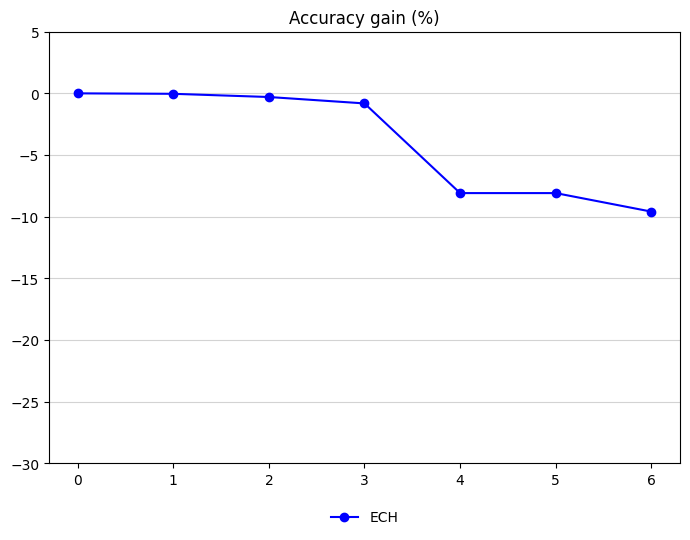

In [137]:
baseline = results[100]
gain_pct = [(results[level] - baseline) / baseline * 100 for level in LEVELS]
positions = list(range(len(LEVELS)))
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(positions, gain_pct, marker="o", color="blue", label=TICKER)
ax.set_ylim(-30, 5)
ax.set_yticks(range(5, -31, -5))
ax.set_xticks(positions)
ax.grid(axis="y", color="lightgray", linewidth=0.8)
ax.set_title("Accuracy gain (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()